# 🏔️ Embed2Heights: Multi-Embedding Fusion for Presence Segmentation & Height Regression

**Team `Attention_Plzzz`** · Dingqi Ye · Daniel Kiv · Wen Zhou · Wei Hu · Ayush Khot

---
#### 🎯 The Task

> Embed2Heights — ["Reaching new heights with GeoFM"(2026)](https://platform.ai4eo.eu/geoai)  
Given only the embeddings of several geospatial foundation models (GeoFMs) for a location, jointly solve two tasks per 256×256 tile:

- **Land-cover presence segmentation** — where are *building*, *vegetation*, and *water*;
- **Height regression** — how tall the surface is (nDSM, in metres).

**Input: 4 foundation models → 6 embedding sources:**

| Source | Shape |
|---|---|
 | **AlphaEarth** | `64 × 256²` |
| **Tessera** | `128 × 256²` |
| **TerraMind** — Sentinel-1 / Sentinel-2 | `768 × 16²` each |
 | **Thor** — Sentinel-1 / Sentinel-2 | `768 × 16²` each |

No raw imagery is provided — the challenge is entirely about **fusing pre-computed GeoFM embeddings**.


#### Goals of the notebook:

1. 🧠 **Introduce the framework** 
2. 📊 **Evaluate the results** 
3. 🔍 **See the strengths and weaknesses**


#### Contents:

[0. Setup](#s0) 

[1. Architecture](#s1)

[2. Quantitative eval](#s2)

[3. Qualitative results](#s3)

[4. Error patterns](#s4)

[5. Strengths & weaknesses](#s5)


<a id="s0"></a>
## 0 · Setup & demo data

The demo assets are hosted in a Hugging Face **dataset** repo and consist of three files:

| file | contents |
|---|---|
| `demo_tiles.npz` | a curated set of OOF tiles with `pred + GT` (float16), spanning best / median / worst cases |
| `oof_metrics.csv` | per-tile metrics over the **entire fold-0** (IoU / RMSE / height bias / GT stats) — used for the error analysis |
| `manifest.json` | thresholds, channel definitions, demo-tile list |


In [14]:
# dependencies (installed on demand on hosted platforms; harmless if already present)
import importlib, subprocess, sys
for pkg in ["huggingface_hub", "pandas"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download

REPO_ID = "DingqiYe/embed2heights-demo"   # <-- change to your HF dataset repo id after uploading

# prefer local notebook_assets/, otherwise download from HF

ASSET_DIR = snapshot_download(repo_id=REPO_ID, repo_type="dataset")
print("downloaded assets from HF:", REPO_ID)

MAN = json.load(open(os.path.join(ASSET_DIR, "manifest.json")))
CH = MAN["channels"]                 # building/vegetation/water/height -> 0/1/2/3
THR = MAN["best_thresholds"]         # per-class binarisation thresholds tuned on OOF
GT_COV = MAN["gt_coverage_threshold"]# presence = coverage > 0.10
df = pd.read_csv(os.path.join(ASSET_DIR, "oof_metrics.csv"))
tiles = np.load(os.path.join(ASSET_DIR, "demo_tiles.npz"))

print(f"fold-{MAN['fold']}  ·  {MAN['n_oof_tiles']} OOF tiles with metrics "
      f"(excluded {MAN.get('n_delmask_excluded', 0)} delmask/bad-GT)  ·  {len(MAN['demo_tiles'])} demo tiles")
print("per-class thresholds:", THR)


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 6944.21it/s]

downloaded assets from HF: DingqiYe/embed2heights-demo
fold-0  ·  361 OOF tiles with metrics (excluded 44 delmask/bad-GT)  ·  13 demo tiles
per-class thresholds: {'building': 0.6, 'vegetation': 0.6, 'water': 0.85}


<a id="s1"></a>
## 1 · Model architecture

Core idea: **fuse the embeddings of several geospatial foundation models (GeoFMs)** and use **a single multi-task network**
to jointly learn *where* building / vegetation / water are (segmentation) and *how tall* they are (regression).

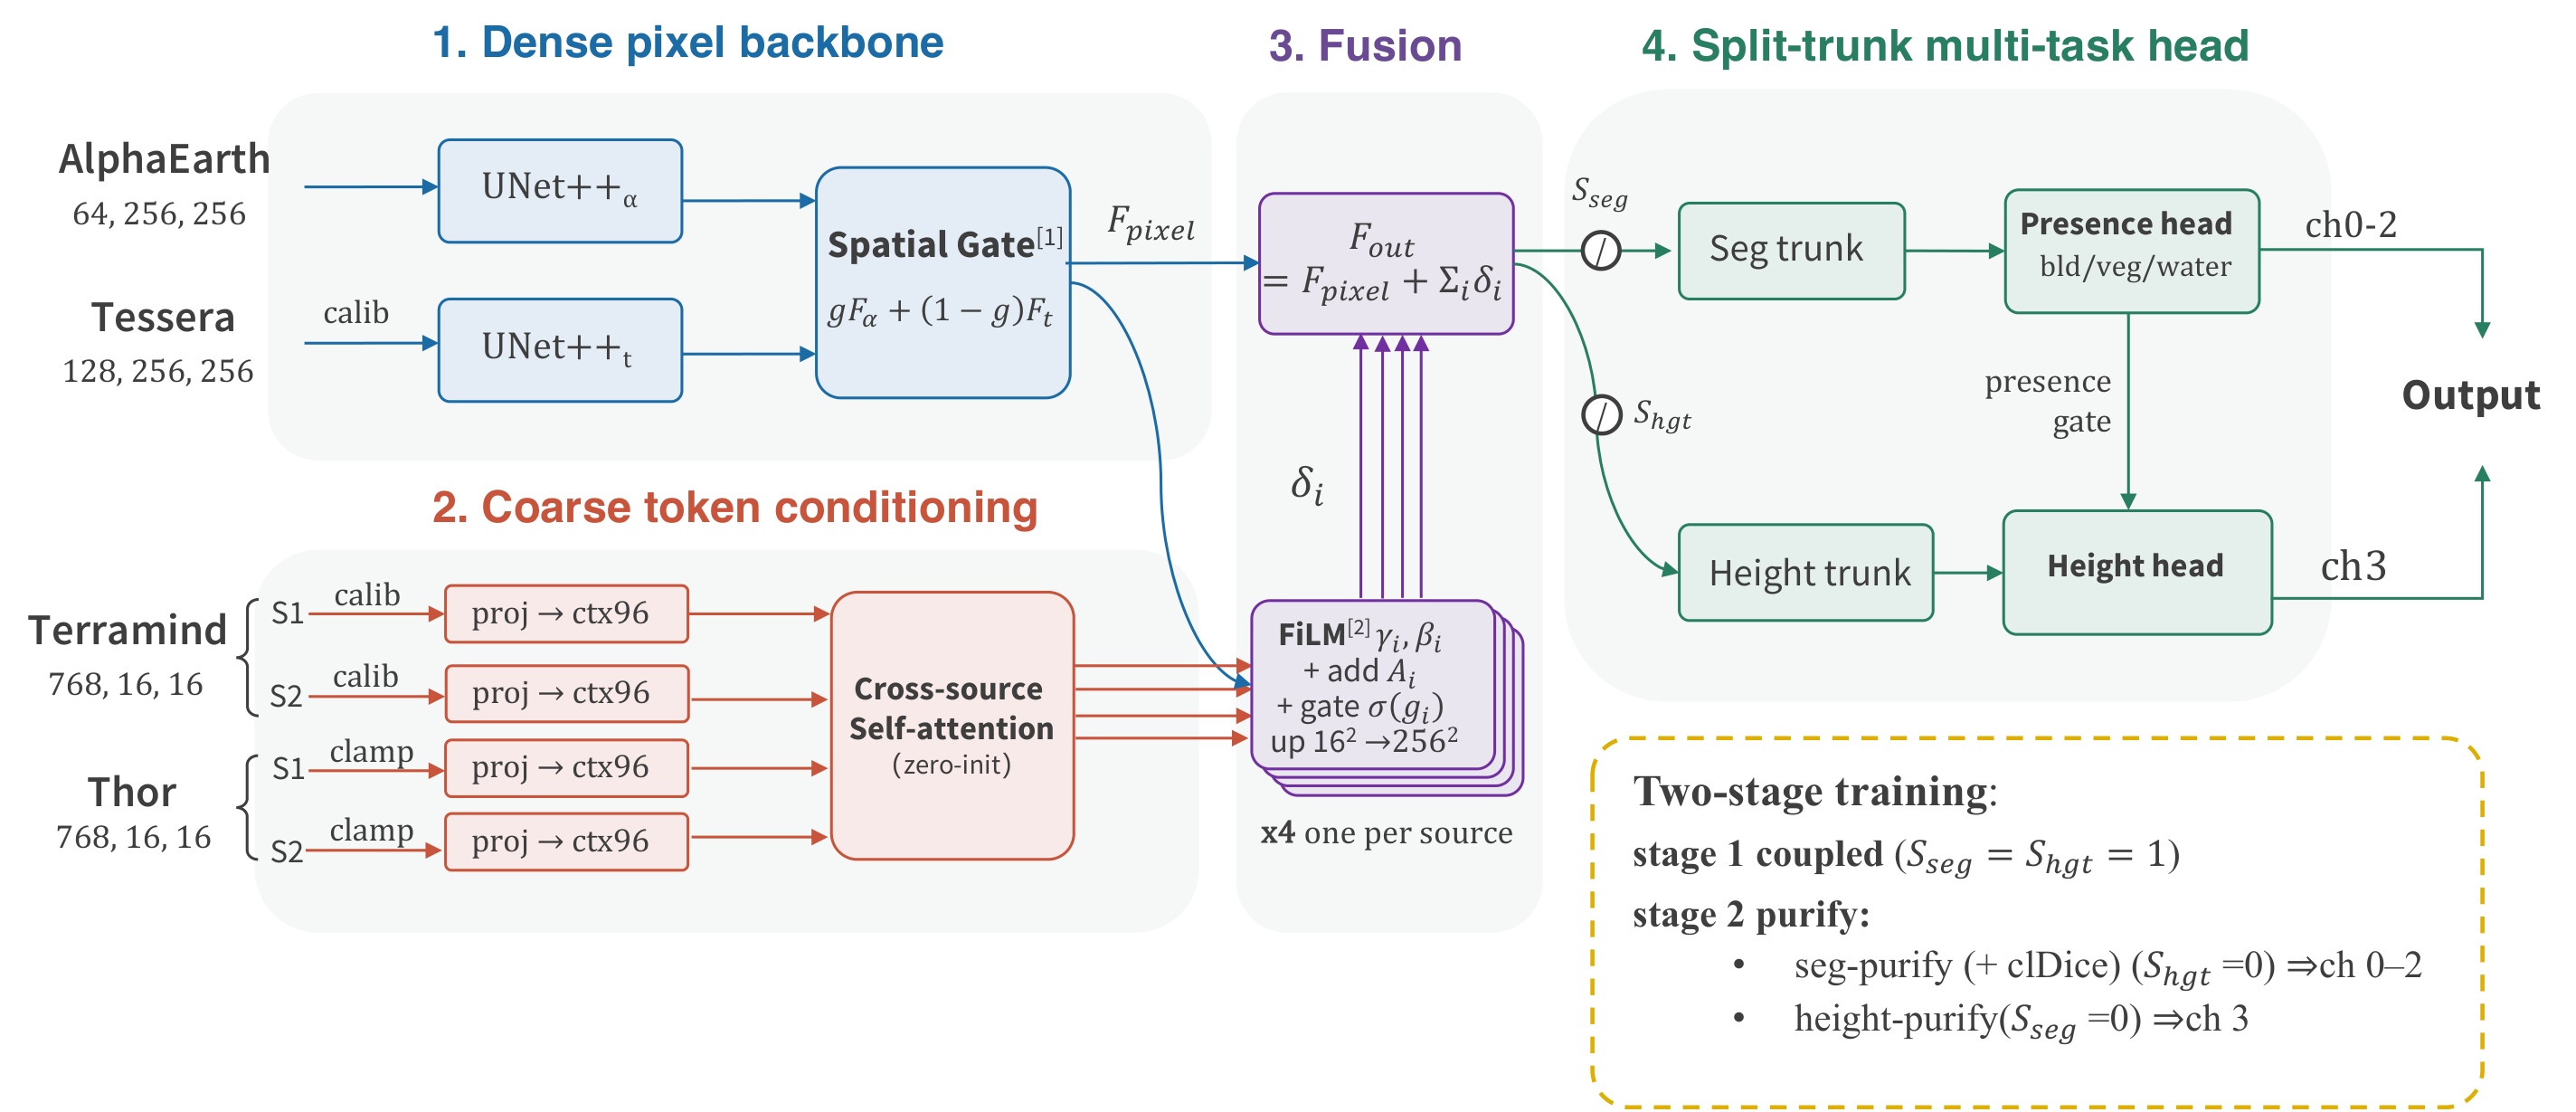

*The four blocks below are explained with runnable code.*

| | Block | What it does |
|---|---|---|
| 🧱 | **Dense pixel backbone** | The dense embeddings (AlphaEarth `64ch` + Tessera `128ch`, both `256²`) each pass through a U-Net++; a learned **spatial gate** fuses them into `F_pixel`. |
| 🎛️ | **Token conditioning** | The 4 coarse token sources (TerraMind / Thor, S1/S2, each `768×16²`) are projected and exchange information via **cross-source self-attention**. |
| 🔀 | **FiLM fusion** | Each token source modulates `F_pixel` with a **zero-init FiLM(γ,β) + additive A + spatial gate σ(g)** residual: `F_out = F_pixel + Σᵢ δᵢ`. Tokens only **condition** the pixel body, never replace it — so it starts as identity and trains stably. |
| 🔱 | **Split-trunk multi-task head** | seg / height have separate trunks, producing presence (ch0-2) and presence-gated height (ch3). |

### 1.1 Instantiate the real model (imported from `core`)

The block below is **not a rewrite** — it imports the **production model itself** from the project's `core/` code
(uses your local copy if present, otherwise shallow-clones it from GitHub), instantiates it on CPU, prints the
parameter count and structure, runs one real forward, and finally prints the **real fusion source** via `inspect`.


In [15]:

import torch, inspect
from core.models import build_model

# xfusion_095_unetpp production config (= the hyper-params in configs/active/xfusion_095_unetpp.yml)
CFG = dict(lightunet_base_ch=48, lightunet_norm_kind="bn",
           height_specialist_depth=1, height_hidden_ch=96, height_trunk_depth=2,
           height_n_bins=64, height_bin_max_m=80.0,
           gate_mode="rich", gate_init_bias=4.0,
           presence_head_depth=1, presence_branch_ch=48, presence_tower_depth=2,
           use_fraction_aux=True, split_trunk=True,
           token_calibration=True, token_calibration_source_indices=[0, 1],
           token_ctx_ch=96, attn_heads=4,
           pixel_backbone_kind="unetpp", use_boundary_head=True)

# n_channels = (pixel_channels, token_channels)
#   pixel = AlphaEarth(64) + Tessera(128) = 192 dense channels
#   token = 4 sources (TerraMind/Thor S1/S2) x 768 = 3072
model, name = build_model("xfusion_unet_hybrid_cross_source",
                          (64 + 128, 4 * 768), n_classes=4, **CFG)
model.eval()

print("model:", name)
print(f"total params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M\n")
print("top-level submodules (real structure breakdown):")
for n, m in model.named_children():
    print(f"  {n:16s} {sum(p.numel() for p in m.parameters())/1e6:6.2f} M")


model: gated_pixel_fusion_hybrid_cross_source
total params: 12.72 M

top-level submodules (real structure breakdown):
  alpha_unet         5.61 M
  tessera_entry      0.02 M
  tessera_unet       5.64 M
  gate_conv          0.01 M
  hybrid_fusion      0.40 M
  head               1.04 M


One **real forward** (pure CPU, random input) — watch the data flow through the four blocks to the 4-channel output:

In [16]:
pixel  = torch.randn(1, 64 + 128, 256, 256)   # AlphaEarth(64)+Tessera(128) dense 256x256
tokens = torch.randn(1, 4 * 768, 16, 16)      # 4 token sources, 768ch each @ 16x16

from core.models.pixel_fusion import _apply_fusion_gate

with torch.no_grad():
    # walk through the model's own submodules to print real intermediate shapes (same as inside model.forward)
    ae  = model.alpha_unet.forward_features(pixel[:, :64])
    tes = model.tessera_unet.forward_features(model.tessera_entry(pixel[:, 64:]))
    F_pixel = _apply_fusion_gate(model.gate_conv, ae, tes, untied=model.gate_untied)
    fused   = model.hybrid_fusion(F_pixel, tokens)   # token conditioning
    out     = model((pixel, tokens))                 # full forward

print(f"AlphaEarth branch feats  : {tuple(ae.shape)}")
print(f"Tessera    branch feats  : {tuple(tes.shape)}")
print(f"spatial-gate fused       : {tuple(F_pixel.shape)}")
print(f"after FiLM conditioning  : {tuple(fused.shape)}")
print(f"multi-task output (4 ch) : {tuple(out.shape)}  = [building, vegetation, water, height]")


AlphaEarth branch feats  : (1, 48, 256, 256)
Tessera    branch feats  : (1, 48, 256, 256)
spatial-gate fused       : (1, 48, 256, 256)
after FiLM conditioning  : (1, 48, 256, 256)
multi-task output (4 ch) : (1, 4, 256, 256)  = [building, vegetation, water, height]


> **zero-init is the key**: in `CrossSourceHybridFiLMFusion` all FiLM/add/gate convolutions, plus the cross-source
> attention `out_proj`, are zero-initialised, so at the start of training `F_out = F_pixel` — the network is equivalent
> to "pixel backbone only" and gradually learns to correct it with the tokens. This makes multi-source fusion very stable to train.

### 1.2 Training & assembly (brief)

- **Two stages**: stage-1 joint seg+height training; stage-2 *dual purify* (freeze one trunk and purify the other, then add clDice on the seg branch).
- **Final submission**: 5 variants (U-Net++ ×3 seeds + UNet3+ + TransUNet) × 5 leave-region-out folds = a **25-model ensemble**,
  plus a per-class linear height calibration (the error analysis below shows why calibration is needed).

*This notebook shows the OOF results of a **single fold-0 model** — because it has GT to compare against; the actual ensembled submission scores higher.*


<a id="s2"></a>
## 2 · Quantitative evaluation (fold-0 OOF)

metric                        mean     std
------------------------------------------
IoU · building             0.510   0.141
IoU · vegetation           0.786   0.160
IoU · water                0.508   0.313
Height RMSE(m) · building    1.493   0.511
Height RMSE(m) · vegetation   2.931   1.358

water IoU  macro(per-tile)=0.508  micro(pixel-pooled)=0.732
  30% of tiles have almost no water; their macro IoU is only 0.396 (pulls the macro mean down)


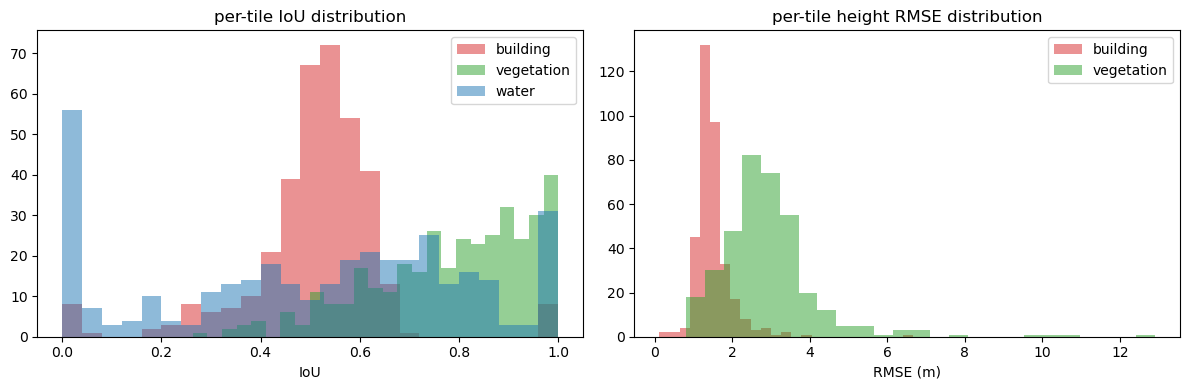

In [17]:
def agg(col):
    v = df[col].dropna()
    return v.mean(), v.std()

print(f"{'metric':<26}{'mean':>8}{'std':>8}")
print("-"*42)
for name in ["building", "vegetation", "water"]:
    m, s = agg(f"iou_{name}")
    print(f"IoU · {name:<18}{m:>8.3f}{s:>8.3f}")
for name in ["building", "vegetation"]:
    m, s = agg(f"rmse_{name}")
    print(f"Height RMSE(m) · {name:<9}{m:>8.3f}{s:>8.3f}")

# water: macro (per-tile mean) vs micro (pixel-pooled) -- empty tiles drag macro down noticeably
tp, fp, fn = (df[f"{k}_water"].sum() for k in ("tp", "fp", "fn"))
print(f"\nwater IoU  macro(per-tile)={df['iou_water'].mean():.3f}  "
      f"micro(pixel-pooled)={tp/(tp+fp+fn):.3f}")
empty = df["gtfrac_water"] < 0.001
print(f"  {empty.mean()*100:.0f}% of tiles have almost no water; their macro IoU is only "
      f"{df.loc[empty,'iou_water'].mean():.3f} (pulls the macro mean down)")

# distribution plots: per-tile IoU / height RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, c in zip(["building", "vegetation", "water"], ["tab:red", "tab:green", "tab:blue"]):
    axes[0].hist(df[f"iou_{name}"].dropna(), bins=25, alpha=0.5, label=name, color=c)
axes[0].set_title("per-tile IoU distribution"); axes[0].set_xlabel("IoU"); axes[0].legend()
for name, c in zip(["building", "vegetation"], ["tab:red", "tab:green"]):
    axes[1].hist(df[f"rmse_{name}"].dropna(), bins=25, alpha=0.5, label=name, color=c)
axes[1].set_title("per-tile height RMSE distribution"); axes[1].set_xlabel("RMSE (m)"); axes[1].legend()
plt.tight_layout(); plt.show()


🌿 **vegetation IoU ≈ 0.79**: the strongest class; over half the tiles score >0.8. Vegetation is spatially contiguous and spectrally distinctive, so it is easiest to segment.

🧱 **building IoU ≈ 0.51**: solid but modest (std only 0.14); buildings are small and fragmented and boundary pixels dominate, so IoU is inherently lower.

💧 **water IoU: macro 0.51 ↔ micro 0.73**: the "average" is misleading. ~30% of tiles have almost no water, where occasional false positives crash the score to ~0.4 under the empty-tile convention, dragging the macro down; the histogram is therefore **U-shaped / bimodal**. The pixel-pooled **micro-IoU 0.73** is the fairer water accuracy (see §4.4).

📏 **Height RMSE: building ≈ 1.5 m / veg ≈ 2.9 m**: building height error is under one storey with a tight distribution; vegetation is ~2× because canopy tops are fuzzy and structurally irregular. *Note: the building mean hides the tall-building underestimation, see §4.1.*


<a id="s3"></a>
## 3 · Qualitative results: pred vs GT

From the demo tiles we take the best / median / worst segmentation cases (by building IoU) and compare per-class probabilities and masks.


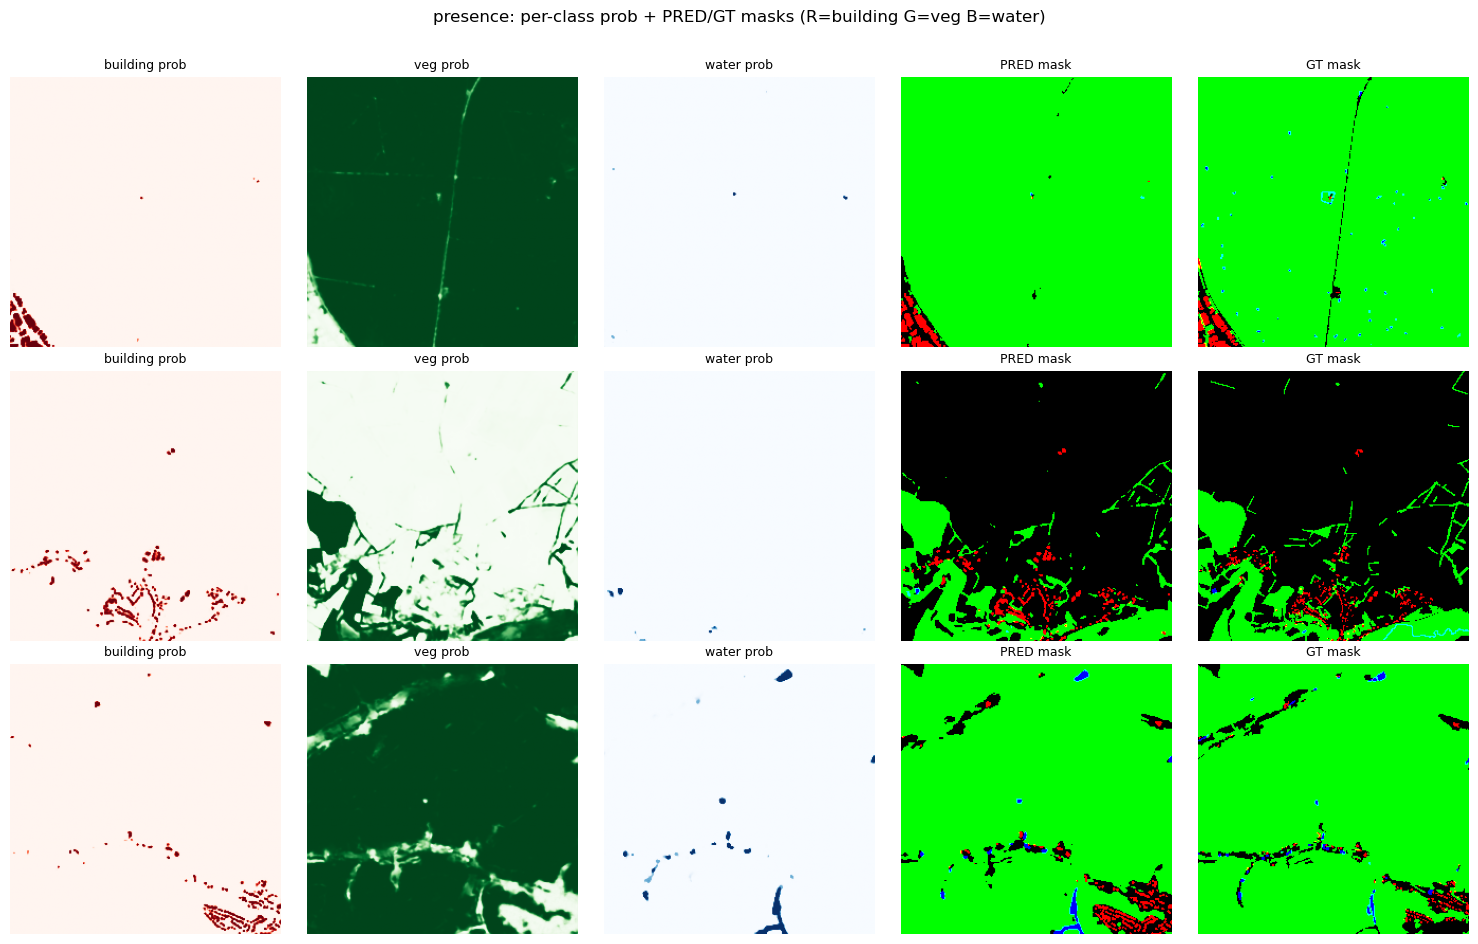

In [18]:
def get(core, kind):        # kind: 'pred' or 'gt'
    return tiles[f"{core}__{kind}"].astype(np.float32)

def presence_rgb(a4, thr):  # 3-class masks -> RGB (building=red, veg=green, water=blue)
    rgb = np.zeros((*a4.shape[1:], 3))
    rgb[..., 0] = a4[CH["building"]]   > thr["building"]
    rgb[..., 1] = a4[CH["vegetation"]] > thr["vegetation"]
    rgb[..., 2] = a4[CH["water"]]      > thr["water"]
    return rgb

roles = MAN["demo_tiles"]
picks = [("seg best",   next(c for c, r in roles.items() if r == "seg_building_best")),
         ("seg median", next(c for c, r in roles.items() if r == "seg_building_median")),
         ("seg worst",  next(c for c, r in roles.items() if r == "seg_building_worst"))]
gt_thr = {k: GT_COV for k in ["building", "vegetation", "water"]}

fig, axes = plt.subplots(len(picks), 5, figsize=(15, 3.1*len(picks)))
for r, (tag, core) in enumerate(picks):
    p, g = get(core, "pred"), get(core, "gt")
    for c, (img, title, cmap) in enumerate([
            (p[CH["building"]],   "building prob", "Reds"),
            (p[CH["vegetation"]], "veg prob",      "Greens"),
            (p[CH["water"]],      "water prob",    "Blues")]):
        axes[r, c].imshow(img, cmap=cmap, vmin=0, vmax=1); axes[r, c].set_title(title, fontsize=9); axes[r, c].axis("off")
    axes[r, 3].imshow(presence_rgb(p, THR));   axes[r, 3].set_title("PRED mask", fontsize=9); axes[r, 3].axis("off")
    axes[r, 4].imshow(presence_rgb(g, gt_thr)); axes[r, 4].set_title("GT mask", fontsize=9);  axes[r, 4].axis("off")
    iou = float(df.loc[df.core == core, "iou_building"].iloc[0])
    axes[r, 0].set_ylabel(f"{tag}\n{core}\nbldIoU={iou:.2f}", fontsize=9, rotation=0, ha="right", va="center")
plt.suptitle("presence: per-class prob + PRED/GT masks (R=building G=veg B=water)", y=1.01)
plt.tight_layout(); plt.show()


Height regression: the best / median / worst building-height cases — GT / prediction / absolute error.

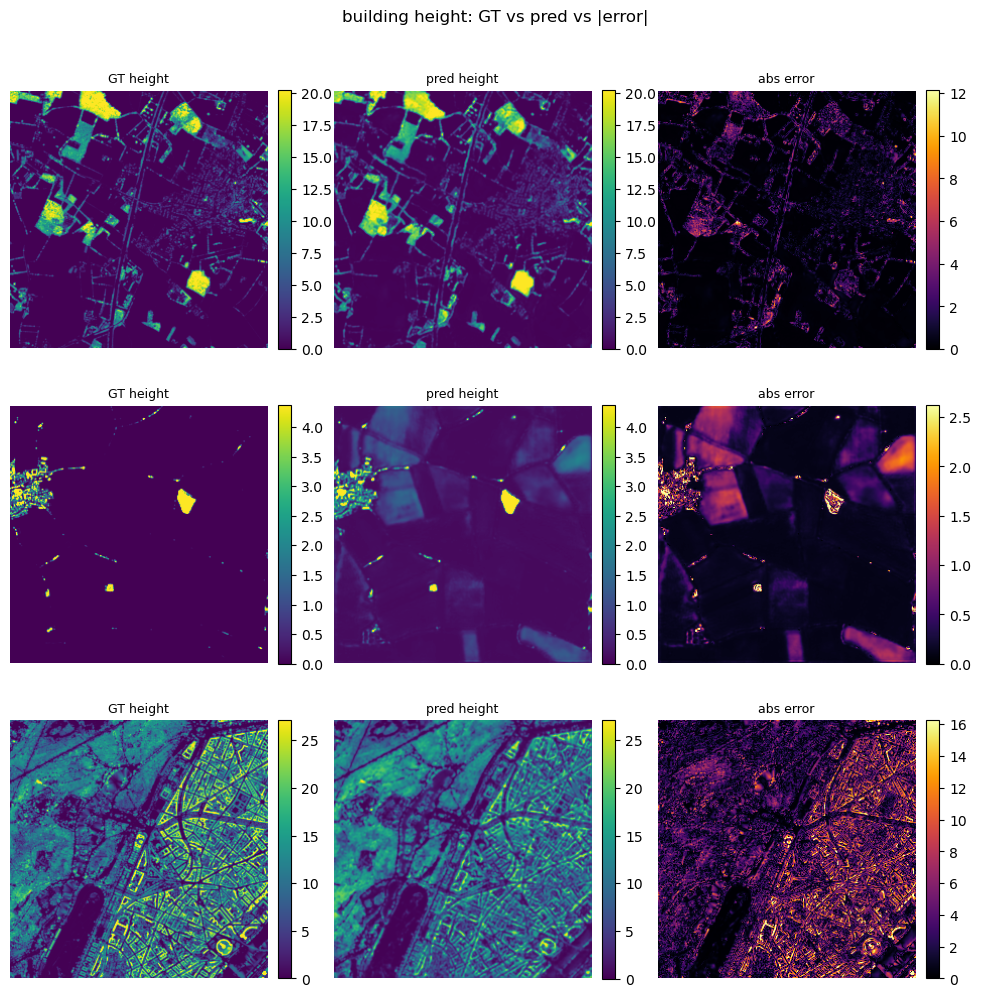

In [19]:
picks_h = [("best",   next(c for c, r in roles.items() if r == "height_building_best")),
           ("median", next(c for c, r in roles.items() if r == "height_building_median")),
           ("worst",  next(c for c, r in roles.items() if r == "height_building_worst"))]

fig, axes = plt.subplots(len(picks_h), 3, figsize=(10, 3.3*len(picks_h)))
for r, (tag, core) in enumerate(picks_h):
    p, g = get(core, "pred"), get(core, "gt")
    gh, ph = g[CH["height"]], p[CH["height"]]
    vmax = max(float(np.percentile(gh, 99)), 1.0)
    for c, (img, title, cmap, vhi) in enumerate([
            (gh,           "GT height",   "viridis", vmax),
            (ph,           "pred height", "viridis", vmax),
            (np.abs(ph-gh),"abs error",   "inferno", vmax*0.6)]):
        im = axes[r, c].imshow(img, cmap=cmap, vmin=0, vmax=vhi); axes[r, c].set_title(title, fontsize=9); axes[r, c].axis("off")
        fig.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)
    rmse = float(df.loc[df.core == core, "rmse_building"].iloc[0])
    axes[r, 0].set_ylabel(f"{tag}\n{core}\nRMSE={rmse:.2f}m", fontsize=9, rotation=0, ha="right", va="center")
plt.suptitle("building height: GT vs pred vs |error|", y=1.01)
plt.tight_layout(); plt.show()


### Dense urban blocks

Dense, tall city blocks are the toughest scenario. The GT below is all **trustworthy** (delmask/bad-GT excluded);
see the model's building masks and height predictions on dense buildings — footprint and height structure track well,
with error concentrated on building edges and the tallest roofs.


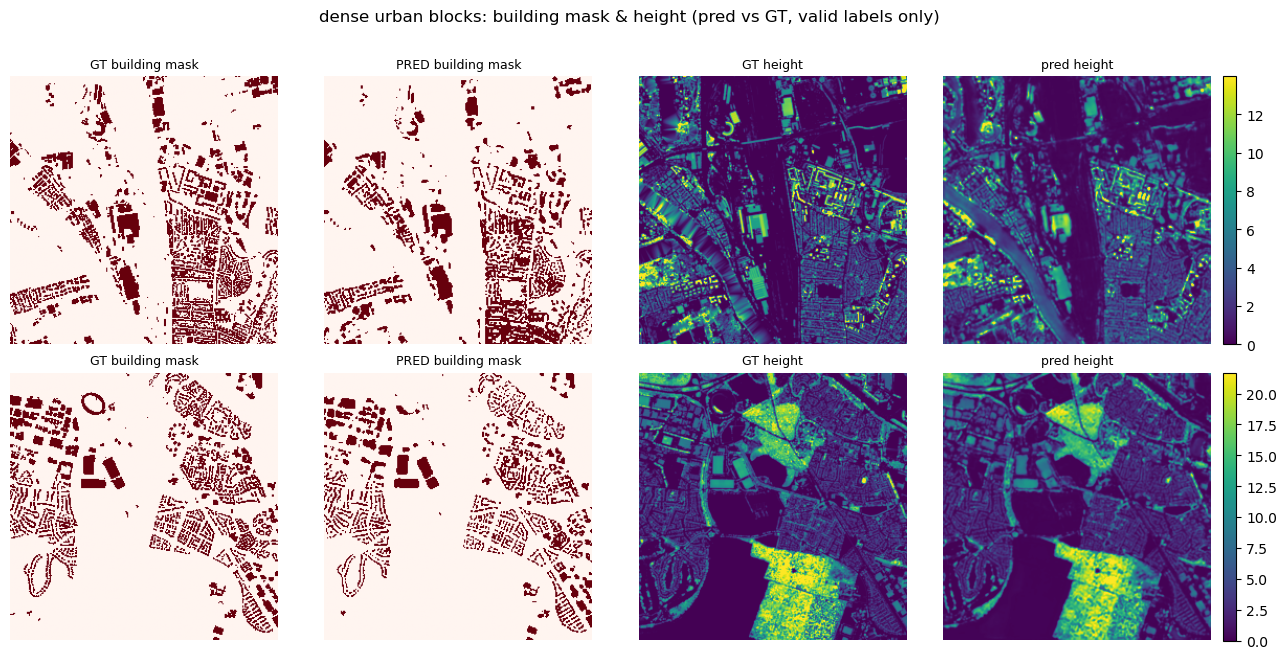

In [20]:
dense_cores = [c for c, r in roles.items() if r == "building_dense"]

fig, axes = plt.subplots(len(dense_cores), 4, figsize=(13, 3.2*len(dense_cores)))
if len(dense_cores) == 1:
    axes = axes[None, :]
for r, core in enumerate(dense_cores):
    p, g = get(core, "pred"), get(core, "gt")
    gh, ph = g[CH["height"]], p[CH["height"]]
    vmax = max(float(np.percentile(gh, 99)), 1.0)
    axes[r, 0].imshow(g[CH["building"]] > GT_COV, cmap="Reds");        axes[r, 0].set_title("GT building mask", fontsize=9)
    axes[r, 1].imshow(p[CH["building"]] > THR["building"], cmap="Reds"); axes[r, 1].set_title("PRED building mask", fontsize=9)
    im2 = axes[r, 2].imshow(gh, cmap="viridis", vmin=0, vmax=vmax);     axes[r, 2].set_title("GT height", fontsize=9)
    im3 = axes[r, 3].imshow(ph, cmap="viridis", vmin=0, vmax=vmax);     axes[r, 3].set_title("pred height", fontsize=9)
    fig.colorbar(im3, ax=axes[r, 3], fraction=0.046, pad=0.04)
    row = df.loc[df.core == core].iloc[0]
    cov = 100 * float(row["gtfrac_building"])
    axes[r, 0].set_ylabel(f"{core}\nbld cover={cov:.0f}%\nIoU={row['iou_building']:.2f}\nRMSE={row['rmse_building']:.2f}m",
                          fontsize=9, rotation=0, ha="right", va="center")
    for a in axes[r]:
        a.axis("off")
plt.suptitle("dense urban blocks: building mask & height (pred vs GT, valid labels only)", y=1.01)
plt.tight_layout(); plt.show()


<a id="s4"></a>
## 4 · Error patterns: where the model is strong and where it is weak

This section uses per-tile metrics over the **entire fold-0** (trustworthy-GT tiles, delmask excluded) to find systematic
failure modes — which is also the motivation for our post-processing / calibration.


### 4.1 Height "range compression": taller buildings are underestimated more

Binning tiles by GT mean building height, we look at the **mean bias** `pred - gt`. The bias becomes monotonically more
negative with height — the model compresses tall buildings down and lifts short ones up (classic regression range compression).
**This is exactly why the final submission applies the linear height calibration `building: h → 1.05h + 0.116`.**


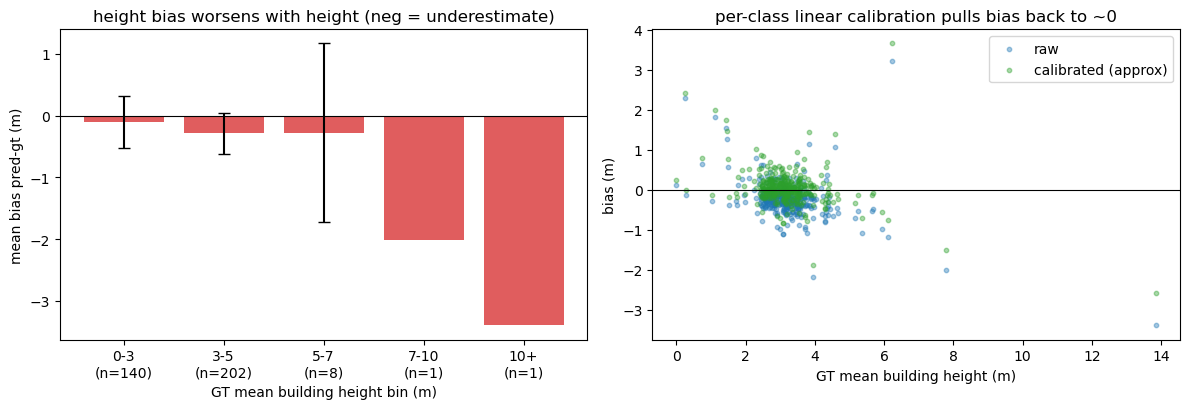

  height  0-3 m : n=140   mean bias = -0.10 m
  height  3-5 m : n=202   mean bias = -0.29 m
  height  5-7 m : n=  8   mean bias = -0.28 m
  height 7-10 m : n=  1   mean bias = -2.01 m
  height  10+ m : n=  1   mean bias = -3.40 m


In [21]:
d = df.dropna(subset=["gtmeanh_building", "bias_building"]).copy()
bins = [0, 3, 5, 7, 10, 100]
labels = ["0-3", "3-5", "5-7", "7-10", "10+"]
d["hbin"] = pd.cut(d["gtmeanh_building"], bins=bins, labels=labels, right=False)
grp = d.groupby("hbin", observed=True)["bias_building"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
means, stds, ns = grp.mean(), grp.std(), grp.size()
a1.bar(range(len(means)), means.values, yerr=stds.values, capsize=4, color="tab:red", alpha=0.75)
a1.axhline(0, color="k", lw=0.8)
a1.set_xticks(range(len(means))); a1.set_xticklabels([f"{l}\n(n={n})" for l, n in zip(means.index, ns.values)])
a1.set_xlabel("GT mean building height bin (m)"); a1.set_ylabel("mean bias pred-gt (m)")
a1.set_title("height bias worsens with height (neg = underestimate)")

# before/after calibration: apply the approximate 1.05*h+0.116 effect to each tile's bias
a2.scatter(d["gtmeanh_building"], d["bias_building"], s=10, alpha=0.4, label="raw")
corr = (1.05*d["gtmeanh_building"]+0.116) - d["gtmeanh_building"] + d["bias_building"]
a2.scatter(d["gtmeanh_building"], corr, s=10, alpha=0.4, color="tab:green", label="calibrated (approx)")
a2.axhline(0, color="k", lw=0.8); a2.set_xlabel("GT mean building height (m)"); a2.set_ylabel("bias (m)")
a2.set_title("per-class linear calibration pulls bias back to ~0"); a2.legend()
plt.tight_layout(); plt.show()

for l, m, n in zip(means.index, means.values, ns.values):
    print(f"  height {l:>4} m : n={n:3d}   mean bias = {m:+.2f} m")


### 4.2 Uneven cross-region generalization (the cost of leave-region-out)

Folds are split **by region** (a whole region is held out for validation), so the OOF metrics directly reflect
**generalization to unseen regions**. Building IoU varies a lot across regions — some have building styles / embedding
distributions that are far off and clearly harder.


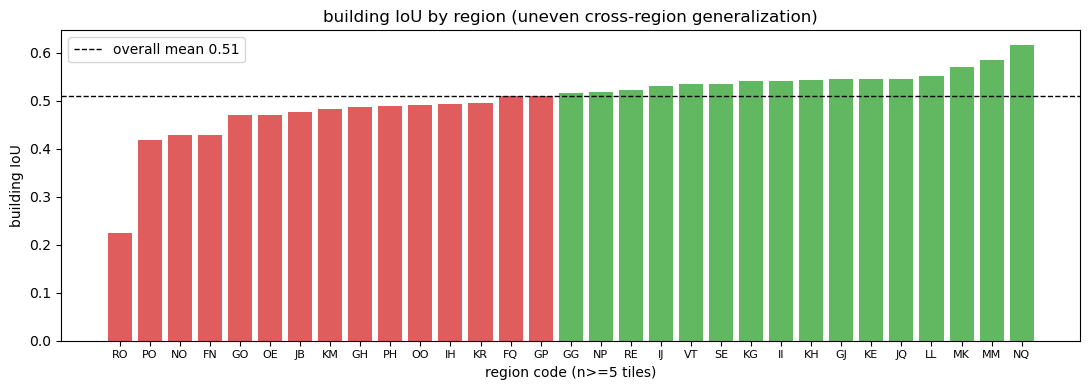

hardest regions: ['RO', 'PO', 'NO']  |  easiest regions: ['MK', 'MM', 'NQ']
=> the 5-fold leave-region-out ensemble is precisely what averages out this regional bias.


In [22]:
reg = df.groupby("region").agg(iou=("iou_building", "mean"), n=("core", "size"))
reg = reg[reg["n"] >= 5].sort_values("iou")
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["tab:red" if v < reg["iou"].median() else "tab:green" for v in reg["iou"]]
ax.bar(range(len(reg)), reg["iou"].values, color=colors, alpha=0.75)
ax.axhline(df["iou_building"].mean(), color="k", ls="--", lw=1, label=f"overall mean {df['iou_building'].mean():.2f}")
ax.set_xticks(range(len(reg))); ax.set_xticklabels(reg.index, rotation=0, fontsize=8)
ax.set_xlabel("region code (n>=5 tiles)"); ax.set_ylabel("building IoU")
ax.set_title("building IoU by region (uneven cross-region generalization)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"hardest regions: {list(reg.index[:3])}  |  easiest regions: {list(reg.index[-3:])}")
print("=> the 5-fold leave-region-out ensemble is precisely what averages out this regional bias.")


### 4.3 Sparse water → false-positive prone

Water pixels are extremely sparse in most tiles. On tiles with **almost no water**, an occasional small false-positive blob
crashes the IoU — which drives the final **water connected-component filter** (removing isolated small blobs).


near-waterless tiles (n=108): water IoU = 0.396
tiles with real water (n=114): water IoU = 0.642


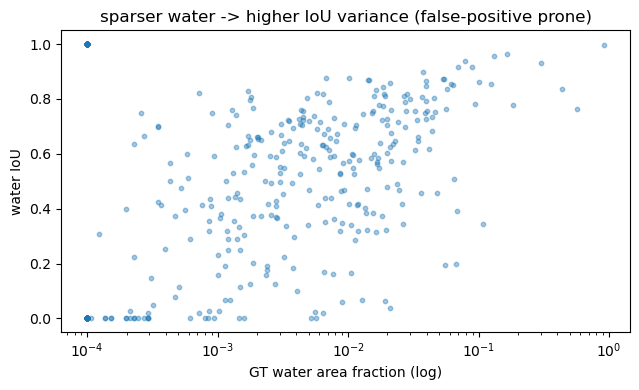

In [23]:
no_water = df[df["gtfrac_water"] < 0.001]
has_water = df[df["gtfrac_water"] >= 0.01]
print(f"near-waterless tiles (n={len(no_water)}): water IoU = {no_water['iou_water'].mean():.3f}")
print(f"tiles with real water (n={len(has_water)}): water IoU = {has_water['iou_water'].mean():.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(df["gtfrac_water"].clip(1e-4, None), df["iou_water"], s=10, alpha=0.4)
ax.set_xscale("log"); ax.set_xlabel("GT water area fraction (log)"); ax.set_ylabel("water IoU")
ax.set_title("sparser water -> higher IoU variance (false-positive prone)")
plt.tight_layout(); plt.show()


**How to read it**: each dot is one tile. On the **far left** (near-waterless), dots split into two clusters — those at 1.0
are "the model also says no water" (the empty-tile convention gives a perfect score), and those crashed to 0 are "a few
false-positive water pixels get heavily penalized"; hence the huge variance in that column. Moving **right** (real water bodies)
the dots cluster higher and tighter — **wherever there is water, it is segmented reliably**.
> Takeaway: the model is not bad at water — it is that **occasional false positives on empty tiles are heavily penalized**. This
> explains both the §2 gap water macro(0.51) ≪ micro(0.73) and the motivation for the **water connected-component filter** (drop
> isolated blobs, rescuing that bottom-left cluster back to 1.0).


### 4.4 IoU error decomposition: false-negative (FN) vs false-positive (FP)

Split each class's IoU **loss** into its sources. At the best threshold, pixel-pooled (micro): `union = TP + FN + FP`,
where `IoU = TP/union`, and the remaining error is either a **miss (FN)** — GT has it, we didn't predict it — or an
**over-prediction (FP)** — we predicted it, GT doesn't have it. Which one dominates tells us which way to improve.

> Note: this is **micro-IoU** (all pixels pooled), a different convention from the per-tile mean IoU in §2 — the latter
> penalizes "empty tiles" more heavily, so the two numbers differ (especially for water).


class        micro-IoU  FN/union  FP/union   FP:FN
building         0.533     0.208     0.258    1.24
vegetation       0.856     0.064     0.080    1.25
water            0.732     0.170     0.097    0.57


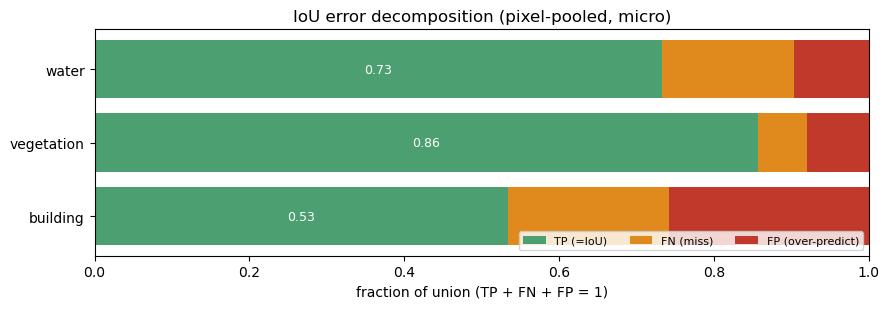


Reading:
  building   - FP ~ FN, balanced errors, slightly over-predicting (edge spillover); segmentation is still the biggest weakness.
  vegetation - highest TP share (~0.86), both miss and over-predict are tiny; the strongest class.
  water      - at the high 0.85 threshold FN>FP, so it misses more than it over-predicts; but FP still hurts per-tile IoU on empty tiles (see 4.3).


In [24]:
classes = ["building", "vegetation", "water"]
colors = {"TP": "#4c9f70", "FN": "#e08a1e", "FP": "#c0392b"}

fig, ax = plt.subplots(figsize=(9, 3.2))
print(f"{'class':<12}{'micro-IoU':>10}{'FN/union':>10}{'FP/union':>10}{'FP:FN':>8}")
for i, c in enumerate(classes):
    TP, FP, FN = df[f"tp_{c}"].sum(), df[f"fp_{c}"].sum(), df[f"fn_{c}"].sum()
    U = TP + FP + FN
    tp, fn, fp = TP/U, FN/U, FP/U
    ax.barh(i, tp,           color=colors["TP"], label="TP (=IoU)" if i == 0 else None)
    ax.barh(i, fn, left=tp,  color=colors["FN"], label="FN (miss)" if i == 0 else None)
    ax.barh(i, fp, left=tp+fn, color=colors["FP"], label="FP (over-predict)" if i == 0 else None)
    ax.text(tp/2, i, f"{tp:.2f}", va="center", ha="center", color="white", fontsize=9)
    print(f"{c:<12}{tp:>10.3f}{fn:>10.3f}{fp:>10.3f}{fp/max(fn,1e-9):>8.2f}")
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("fraction of union (TP + FN + FP = 1)")
ax.set_xlim(0, 1); ax.set_title("IoU error decomposition (pixel-pooled, micro)")
ax.legend(loc="lower right", fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

print("\nReading:")
print("  building   - FP ~ FN, balanced errors, slightly over-predicting (edge spillover); segmentation is still the biggest weakness.")
print("  vegetation - highest TP share (~0.86), both miss and over-predict are tiny; the strongest class.")
print("  water      - at the high 0.85 threshold FN>FP, so it misses more than it over-predicts; but FP still hurts per-tile IoU on empty tiles (see 4.3).")


<a id="s5"></a>
## 5 · Strengths & weaknesses

### ✅ Strengths
- **Stable, effective multi-source fusion**: zero-init FiLM lets token embeddings correct the pixel backbone in a *conditioning* way — identity at init, stable training; vegetation IoU ≈ **0.79**.
- **Multi-task + split-trunk**: segmentation and height share features but have **separate trunks**, so they don't fight over gradients; 4 channels from one forward.
- **Targeted engineering**: delmask (fixing ~100 tiles with human-deleted building footprints), boundary head, clDice refinement, and the leave-region-out ensemble each add measurable gains.

### ⚠️ Weaknesses & our mitigations
| Weakness | Evidence | Mitigation |
|---|---|---|
| Tall-building **height underestimation** (range compression) | 10 m+ buildings, mean bias ≈ **−3 m** | per-class linear calibration `1.05h+0.116` |
| **Uneven cross-region generalization** | building IoU 0.2 → 0.6 across regions | 5-fold leave-region-out **ensemble** |
| water **sparse & false-positive prone** | waterless tiles have clearly lower IoU | **connected-component filter** post-processing |
| building segmentation is still the weak spot | building IoU ≈ **0.51** < veg 0.79; errors FP≈FN, slightly over-predicting (§4.4) | boundary head + clDice + ensemble |


